<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/DBSCAN/DBSCAN_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DBSCAN Scratch

In [2]:
import numpy as np

class DBSCANScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    def fit(self, X):
        n_samples = X.shape[0]
        self.labels = np.full(n_samples, -1) # -1 means Noise/Unvisited
        cluster_id = 0

        for i in range(n_samples):
            if self.labels[i] != -1: # Already processed
                continue

            neighbors = self._get_neighbors(X, i)

            if len(neighbors) < self.min_samples:
                self.labels[i] = -2 # Temporarily mark as noise
            else:
                self._expand_cluster(X, i, neighbors, cluster_id)
                cluster_id += 1

        # Reset temp noise (-2) to final noise (-1)
        self.labels[self.labels == -2] = -1

    def _expand_cluster(self, X, point_idx, neighbors, cluster_id):
        self.labels[point_idx] = cluster_id

        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]

            if self.labels[neighbor_idx] == -2: # Change noise to border point
                self.labels[neighbor_idx] = cluster_id
            elif self.labels[neighbor_idx] == -1: # Unvisited
                self.labels[neighbor_idx] = cluster_id
                new_neighbors = self._get_neighbors(X, neighbor_idx)
                if len(new_neighbors) >= self.min_samples:
                    neighbors = np.concatenate([neighbors, new_neighbors])
            i += 1

    def _get_neighbors(self, X, point_idx):
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0]

DBSCAN Class Model

In [3]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# 1. Create non-linear data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# 2. Fit model
db = DBSCANScratch(eps=0.2, min_samples=5)
db.fit(X)

Execution

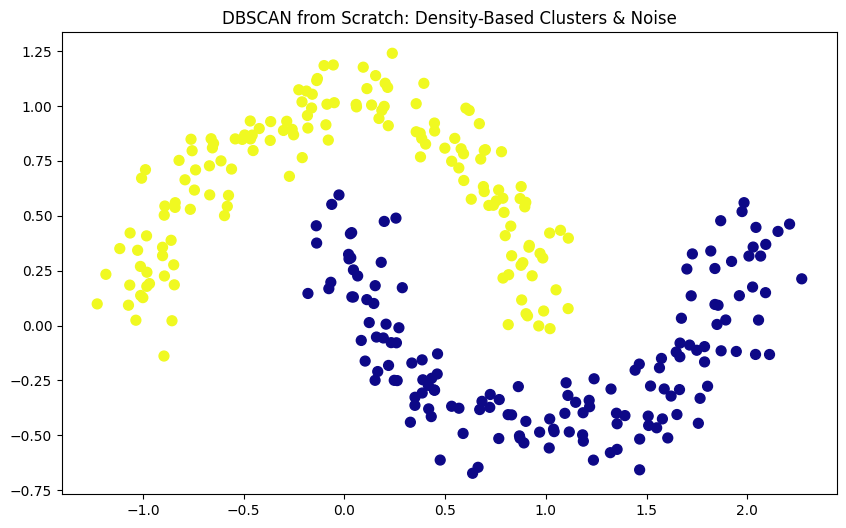

In [4]:
# 3. Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=db.labels, cmap='plasma', s=50)
plt.title("DBSCAN from Scratch: Density-Based Clusters & Noise")
plt.show()

2D Visualization

In [5]:
import plotly.graph_objects as go

# Generate 3D data with lots of noise
X_3d, _ = make_moons(n_samples=200, noise=0.1, random_state=7)
noise = np.random.uniform(-1.5, 2.5, (50, 2))
X_combined = np.vstack([X_3d, noise])
# Add a dummy 3rd dimension
X_final = np.hstack([X_combined, np.reshape(X_combined[:,0]**2, (-1, 1))])

db_3d = DBSCANScratch(eps=0.3, min_samples=3)
db_3d.fit(X_final)

fig = go.Figure(data=[
    go.Scatter3d(x=X_final[:,0], y=X_final[:,1], z=X_final[:,2],
                 mode='markers', marker=dict(size=4, color=db_3d.labels, colorscale='Viridis'))
])
fig.update_layout(title="3D DBSCAN: Isolating Dense Manifolds and Noise")
fig.show()

3D Visualization

introduced the concept of Topological Clustering. Unlike K-Means, which assumes every cluster has a center and a radius, DBSCAN only assumes that clusters are areas of high density separated by areas of low density. This makes it incredibly powerful for real-world sensor data where you might have "streaks" of data points or random interference (noise). The algorithm's ability to label points as -1 (Noise) is a built-in Anomaly Detection system. For your AccessLens project or drone flight paths, this is how you separate meaningful movement from random jitter.